In [42]:
from cd.algs.cd_poly import CDPolynomial, plot_contours
from sklearn.svm import OneClassSVM

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [106]:
n = 20_000

mu1 = np.array([-2., 0])
sig1 = np.array([[.2, .0,], [.0, 4.]])
z1 = multivariate_normal(mu1, sig1).rvs(n // 2)

mu2 = np.array([2., 0])
sig2 = np.array([[3., 0.,], [0., .2]])
z2 = multivariate_normal(mu2, sig2).rvs(n // 2)

z = np.concatenate([z1, z2])

In [107]:
# nu: prob of finding a regular observation outside the frontier
# nu bigger -> tighter boundary
svm = OneClassSVM(kernel='rbf', nu=.25, gamma=1/np.sqrt(2))
svm.fit(z)

,kernel,'rbf'
,degree,3
,gamma,np.float64(0.7071067811865475)
,coef0,0.0
,tol,0.001
,nu,0.25
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


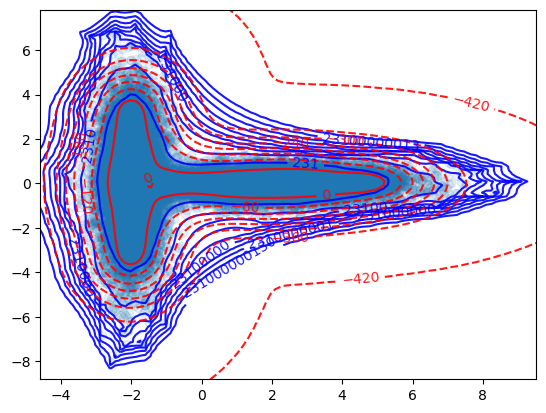

In [112]:
p = CDPolynomial(z, 20, method='qr')
plt.scatter(*z.T, alpha=.1)

p.plot(plt.gca(), colors='blue')
plot_contours(svm.decision_function, plt.gca(), colors='red')